# Model generation & validation
We will try a few different classifier to create a model which can predict customer churning for the provided energy data, we will be try a few different modelling techniques here-

1. logistic regression
2. random forest
3. xgboost
4. lightGBM

In [115]:
import sys, os, glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.tree import DecisionTreeClassifier
# importing nessaary util functions
sys.path.append(os.path.abspath(os.path.join(os.path.dirname("../"), ".")))
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [116]:
# importing nessaary util functions
from utils.utils import split_data, apply_smote, train_model, tune_model_with_gridsearch, run_multiple_classifiers

In [117]:
# processed_df_path should go in the config.yaml
df_path = "../data/processed/churn_data_feat_eng_1.csv"
df = pd.read_csv(df_path)

In [118]:
df.head()

,UsageData,BillingAmount,PaymentHistory,CustomerServiceInteractions,Complaints,PromotionsReceived,ContractType,ContractDuration,Age,Gender,Income,HouseholdSize,Month,HighUsageFlag,CostPerUnit,BilltoIncomeRatio,IsShortContractedCust,EngagementScore,Income_x_Complaints,Billing_x_ContractLength,Gender_x_Complaints,Promo_x_PaymentHistory,UsageData_squared,Age_x_Usage,ContractType_x_CSInteractions,Billing_x_Income,is_churned
0,880.922970,100.441977,1,2,0,0,1,16,18,0,57732,2,1,1,0.114019,574.779608,0,2,0,1607.071626,0,0,776025.279639,15856.613466,2,0.001740,0
1,495.978553,176.144725,1,1,0,2,1,12,51,0,84085,3,1,0,0.355146,477.363145,0,3,0,2113.736702,0,2,245994.725453,25294.906224,1,0.002095,0
2,311.763191,145.690171,1,2,0,0,0,15,21,1,51898,5,1,0,0.467310,356.221697,0,2,0,2185.352567,0,0,97196.287248,6547.027010,0,0.002807,0
3,414.412773,105.305217,1,4,1,3,1,13,23,0,72227,3,1,0,0.254107,685.882448,0,6,72227,1368.967820,0,3,171737.946412,9531.493779,4,0.001458,0
4,244.697028,52.308319,1,5,2,3,0,17,41,1,37707,1,1,0,0.213768,720.860481,0,6,75414,889.241423,2,3,59876.635355,10032.578135,0,0.001387,0


In [119]:
df.columns

Index(['UsageData', 'BillingAmount', 'PaymentHistory',
       'CustomerServiceInteractions', 'Complaints', 'PromotionsReceived',
       'ContractType', 'ContractDuration', 'Age', 'Gender', 'Income',
       'HouseholdSize', 'Month', 'HighUsageFlag', 'CostPerUnit',
       'BilltoIncomeRatio', 'IsShortContractedCust', 'EngagementScore',
       'Income_x_Complaints', 'Billing_x_ContractLength',
       'Gender_x_Complaints', 'Promo_x_PaymentHistory', 'UsageData_squared',
       'Age_x_Usage', 'ContractType_x_CSInteractions', 'Billing_x_Income',
       'is_churned'],
      dtype='object')

In [120]:
# excluded features from PCA
excluded_from_scaling = ['IsShortContractedCust', 'HighUsageFlag', 'ContractType', 'Gender', 'PaymentHistory']

X_train, X_test, y_train, y_test, scaler, pca_model = split_data(
    df=df,
    target='is_churned',
    scale=False,
    test_size=0.2,
    pca=False,
    exclude_from_pca=excluded_from_scaling
)

In [121]:
X_test.head()

,UsageData,BillingAmount,CustomerServiceInteractions,Complaints,PromotionsReceived,ContractDuration,Age,Income,HouseholdSize,Month,CostPerUnit,BilltoIncomeRatio,EngagementScore,Income_x_Complaints,Billing_x_ContractLength,Gender_x_Complaints,Promo_x_PaymentHistory,UsageData_squared,Age_x_Usage,ContractType_x_CSInteractions,Billing_x_Income,IsShortContractedCust,HighUsageFlag,ContractType,Gender,PaymentHistory
7979,387.610388,135.443810,0,0,3,10,69,89659,3,9,0.349433,661.964546,3,0,1354.438097,0,3,150241.813216,26745.116801,0,0.001511,0,0,0,1,1
3220,495.978553,100.441977,0,1,1,14,25,87371,5,4,0.202513,869.865398,0,87371,1406.187673,0,1,245994.725453,12399.463836,0,0.001150,0,0,1,0,1
4708,919.276716,101.117758,3,0,2,3,45,49871,4,5,0.109997,493.197251,5,0,303.353273,0,2,845069.679975,41367.452205,3,0.002028,1,1,1,1,1
618,915.710723,27.842423,5,1,0,8,49,105707,2,1,0.030405,3796.616412,4,105707,222.739384,1,0,838526.127609,44869.825411,0,0.000263,0,1,0,1,1
6524,644.907591,187.326797,4,1,0,3,39,110305,3,7,0.290471,588.837272,3,110305,561.980391,1,0,415905.800926,25151.396049,4,0.001698,1,0,1,1,1


In [122]:
X_train.head()

,UsageData,BillingAmount,CustomerServiceInteractions,Complaints,PromotionsReceived,ContractDuration,Age,Income,HouseholdSize,Month,CostPerUnit,BilltoIncomeRatio,EngagementScore,Income_x_Complaints,Billing_x_ContractLength,Gender_x_Complaints,Promo_x_PaymentHistory,UsageData_squared,Age_x_Usage,ContractType_x_CSInteractions,Billing_x_Income,IsShortContractedCust,HighUsageFlag,ContractType,Gender,PaymentHistory
9937,369.119034,61.404314,5,0,0,3,54,103369,1,11,0.166354,1683.415911,5,0,184.212943,0,0,136248.861132,19932.427827,0,0.000594,1,0,0,0,1
11053,353.305778,102.835230,0,1,0,9,38,108879,2,12,0.291066,1058.771393,-1,108879,925.517072,1,0,124824.973038,13425.619579,0,0.000944,0,0,0,1,1
4523,857.394625,109.098951,0,0,1,14,20,62151,1,5,0.127245,569.675507,1,0,1527.385307,0,1,735125.543361,17147.892504,0,0.001755,0,1,0,1,1
7829,996.188967,111.949729,0,1,2,7,44,83803,1,8,0.112378,748.577072,1,83803,783.648100,0,2,992392.457445,43832.314536,0,0.001336,0,1,0,0,1
5417,502.087897,89.367405,3,2,0,1,43,105561,4,6,0.177992,1181.202474,1,211122,89.367405,0,0,252092.256332,21589.779572,0,0.000847,1,0,0,0,1


In [123]:
# Calculate scale_pos_weight for XGBoost
scale_pos_weight = len(y_train) / sum(y_train)

model_list = [
    ('logistic', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    ('random_forest', RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)),
    ('svm', SVC(probability=True, class_weight='balanced', random_state=42)),
    ('xgboost', XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=scale_pos_weight, random_state=42)),
    ('lightgbm', LGBMClassifier(random_state=42)),
    ('decision_tree', DecisionTreeClassifier(random_state=42, class_weight='balanced')),
    ('grad_boost', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42))
]

In [124]:
results, fitted_model_1 = run_multiple_classifiers(X_train, X_test, y_train, y_test,
                              model_list=model_list,
                              lift_cutoffs=[0.1, 0.2])

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [00:35:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 926, number of negative: 8610
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001013 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2701
[LightGBM] [Info] Number of data points in the train set: 9536, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.097106 -> initscore=-2.229805
[LightGBM] [Info] Start training from score -2.229805


In [125]:
results

,model,precision,recall,f1_score,lift_at_top_10%,lift_at_top_20%
0,logistic,0.091,0.418,0.150,1.036,0.907
1,random_forest,0.000,0.000,0.000,0.993,0.993
2,svm,0.000,0.000,0.000,0.777,0.648
3,xgboost,0.073,0.056,0.063,0.993,0.928
4,lightgbm,0.000,0.000,0.000,0.777,0.777
5,decision_tree,0.097,0.086,0.091,0.950,0.950
6,grad_boost,0.000,0.000,0.000,1.209,1.015


/var/folders/7w/dgslt9rx39qb89n089jly0tm0000gn/T/ipykernel_84340/2571727334.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='viridis')


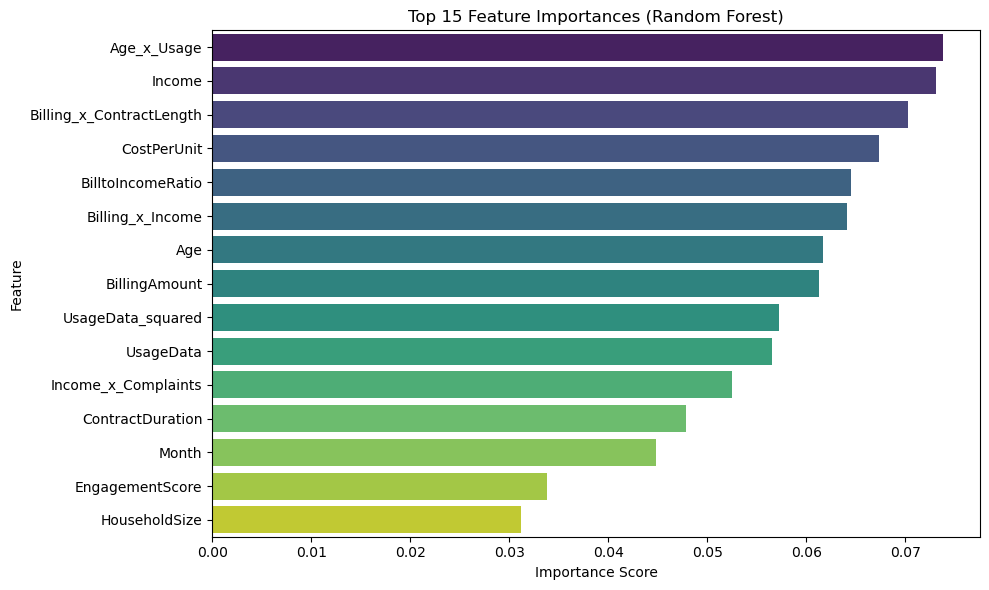

In [126]:
from sklearn.ensemble import RandomForestClassifier
X = X_train
y = y_train

#Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight= 'balanced')
rf.fit(X, y)

#Get feature importances
importances = rf.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

#Plot top features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [127]:
y_train.value_counts()

is_churned
0    8610
1     926
Name: count, dtype: int64

There is massive class imbalance in the dataset, which is common amongst churn problems, I will fix it using two techniques-
1. RandomUnderSampler, which reduces the noise from the not_churned customers.
2. OverSampling using SMOTE, which increases the class size for the churned users.

In [128]:
# simple under-sampling
#from imblearn.under_sampling import RandomUnderSampler
#rus = RandomUnderSampler(sampling_strategy={0:3000, 1:934}, random_state=42)
#X_train_resampled, y_train_resampled = rus.fit_resample(X_train, y_train)

In [129]:
#y_train_resampled.value_counts()


In [130]:
# Apply cube centriods to the training set only

X_train_bal, y_train_bal = apply_smote(X_train, y_train, 
                                               excluded_from_scaling=excluded_from_scaling, scale=False, tomek=True)
X_train_bal = pd.DataFrame(X_train_bal, columns=X_train.columns)

In [131]:
y_train_bal.value_counts()

is_churned
0    8180
1    3875
Name: count, dtype: int64

In [132]:
#undersample using centroids, scaling is set false as it was already done in previous step
X_train_bal, y_train_bal = apply_smote(X_train_bal, y_train_bal, 
                                               excluded_from_scaling=excluded_from_scaling, scale=False, cube=True)
X_train_bal = pd.DataFrame(X_train_bal, columns=X_train.columns)

In [133]:
X_train_bal.head()

,UsageData,BillingAmount,CustomerServiceInteractions,Complaints,PromotionsReceived,ContractDuration,Age,Income,HouseholdSize,Month,CostPerUnit,BilltoIncomeRatio,EngagementScore,Income_x_Complaints,Billing_x_ContractLength,Gender_x_Complaints,Promo_x_PaymentHistory,UsageData_squared,Age_x_Usage,ContractType_x_CSInteractions,Billing_x_Income,IsShortContractedCust,HighUsageFlag,ContractType,Gender,PaymentHistory
0,546.832718,72.393233,0,1,2,18,58,55732,5,2,0.132386,7.698510e+02,1,55732,1303.078203,0,2,299026.021632,31716.297652,0,1.298929e-03,0,0,1,0,1
1,839.454148,100.441977,4,0,3,19,61,79615,8,3,0.119652,7.926467e+02,7,0,1908.397556,0,3,704683.266880,51206.703038,4,1.261580e-03,0,1,1,1,1
2,765.397623,0.005248,5,1,2,4,39,89587,3,3,0.000007,1.706942e+07,6,89587,0.020994,1,2,585833.520854,29850.507286,5,5.858365e-08,1,1,1,1,1
3,233.520531,100.441977,0,2,2,24,31,51917,4,7,0.430121,5.168855e+02,0,103834,2410.607439,0,2,54531.838615,7239.136475,0,1.934627e-03,0,0,1,0,1
4,915.024700,169.275563,2,1,3,11,51,43755,5,12,0.184996,2.584839e+02,4,43755,1862.031188,1,0,837270.202118,46666.259714,2,3.868625e-03,0,1,1,1,0


In [134]:
y_train_bal.value_counts()

is_churned
0    7750
1    3875
Name: count, dtype: int64

In [135]:
X_train_bal.shape

(11625, 26)

In [136]:
X_test.shape

(2384, 26)

#### Feature importance after undersampling with cubeCentroids

/var/folders/7w/dgslt9rx39qb89n089jly0tm0000gn/T/ipykernel_84340/2387528509.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='viridis')


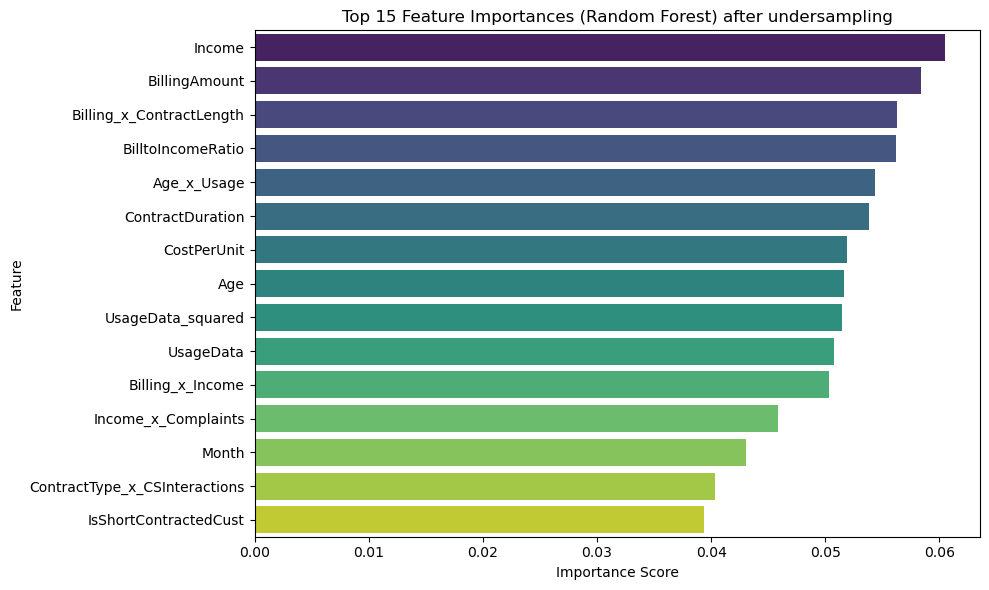

In [137]:
from sklearn.ensemble import RandomForestClassifier

# Prepare data
X = X_train_bal
y = y_train_bal

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight= 'balanced')
rf.fit(X, y)

# Get feature importances
importances = rf.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot top features
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title("Top 15 Feature Importances (Random Forest) after undersampling")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [138]:
X_train_bal.head()

,UsageData,BillingAmount,CustomerServiceInteractions,Complaints,PromotionsReceived,ContractDuration,Age,Income,HouseholdSize,Month,CostPerUnit,BilltoIncomeRatio,EngagementScore,Income_x_Complaints,Billing_x_ContractLength,Gender_x_Complaints,Promo_x_PaymentHistory,UsageData_squared,Age_x_Usage,ContractType_x_CSInteractions,Billing_x_Income,IsShortContractedCust,HighUsageFlag,ContractType,Gender,PaymentHistory
0,546.832718,72.393233,0,1,2,18,58,55732,5,2,0.132386,7.698510e+02,1,55732,1303.078203,0,2,299026.021632,31716.297652,0,1.298929e-03,0,0,1,0,1
1,839.454148,100.441977,4,0,3,19,61,79615,8,3,0.119652,7.926467e+02,7,0,1908.397556,0,3,704683.266880,51206.703038,4,1.261580e-03,0,1,1,1,1
2,765.397623,0.005248,5,1,2,4,39,89587,3,3,0.000007,1.706942e+07,6,89587,0.020994,1,2,585833.520854,29850.507286,5,5.858365e-08,1,1,1,1,1
3,233.520531,100.441977,0,2,2,24,31,51917,4,7,0.430121,5.168855e+02,0,103834,2410.607439,0,2,54531.838615,7239.136475,0,1.934627e-03,0,0,1,0,1
4,915.024700,169.275563,2,1,3,11,51,43755,5,12,0.184996,2.584839e+02,4,43755,1862.031188,1,0,837270.202118,46666.259714,2,3.868625e-03,0,1,1,1,0


#### Use only PCA feature to train the models

In [140]:
# Calculate scale_pos_weight for XGBoost
scale_pos_weight = len(y_train) / sum(y_train)

model_list = [
    ('logistic', LogisticRegression(max_iter=1000,  random_state=42)),
    ('random_forest', RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')),
    ('svm', SVC(probability=True, random_state=42)),
    ('xgboost', XGBClassifier(use_label_encoder=False, scale_pos_weight=scale_pos_weight, random_state=42)),
    ('lightgbm', LGBMClassifier(random_state=42)),
    ('decision_tree', DecisionTreeClassifier(random_state=42)),
    ('grad_boost', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42))
]

In [141]:
results_smote, fitted_model_3 = run_multiple_classifiers(X_train_bal, X_test, y_train_bal, y_test,
                              model_list=model_list,
                              lift_cutoffs=[0.1, 0.2])

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [00:36:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 3875, number of negative: 7750
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000630 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2701
[LightGBM] [Info] Number of data points in the train set: 11625, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333333 -> initscore=-0.693147
[LightGBM] [Info] Start training from score -0.693147


In [142]:
results_smote

,model,precision,recall,f1_score,lift_at_top_10%,lift_at_top_20%
0,logistic,0.000,0.000,0.000,1.123,0.950
1,random_forest,0.172,0.043,0.069,1.123,1.036
2,svm,0.000,0.000,0.000,1.511,1.144
3,xgboost,0.092,0.211,0.128,0.907,0.950
4,lightgbm,0.169,0.043,0.069,1.036,0.971
5,decision_tree,0.110,0.203,0.143,1.079,1.058
6,grad_boost,0.094,0.022,0.035,1.209,1.079


In [143]:
# let's adjust the classification thresold-
results_smote_adj_thresold, fitted_models = run_multiple_classifiers(X_train_bal, X_test, y_train_bal, y_test,
                              model_list=model_list,
                              threshold=0.3,
                              lift_cutoffs=[0.1, 0.2])

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [00:36:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 3875, number of negative: 7750
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000485 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2701
[LightGBM] [Info] Number of data points in the train set: 11625, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.333333 -> initscore=-0.693147
[LightGBM] [Info] Start training from score -0.693147


In [144]:
results_smote_adj_thresold

,model,precision,recall,f1_score,lift_at_top_10%,lift_at_top_20%
0,logistic,0.096,0.828,0.173,1.123,0.950
1,random_forest,0.106,0.164,0.128,1.123,1.036
2,svm,0.097,1.000,0.177,1.511,1.144
3,xgboost,0.089,0.366,0.143,0.907,0.950
4,lightgbm,0.092,0.125,0.106,1.036,0.971
5,decision_tree,0.110,0.203,0.143,1.079,1.058
6,grad_boost,0.103,0.254,0.147,1.209,1.079


#### Stacked ensemble model using meta_learner as lightGBM

#### Hyper parameter tuning

In [145]:
xgb_model, xgb_best_params = tune_model_with_gridsearch(X_train_bal, y_train_bal, model_type='xgboost', scoring='f1')
print("Best Parameters:", xgb_best_params)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [00:36:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [00:36:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [00:36:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/anaconda3/lib/python3.12/site-packages/xgboost/training.py:183: UserWarning: [00:36:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i

Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'scale_pos_weight': 1, 'subsample': 0.8}


In [146]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1] if hasattr(xgb_model, "predict_proba") else None
metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'f1_score': f1_score(y_test, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_prob) if y_prob is not None else 'N/A'
}

In [147]:
metrics

{'accuracy': 0.886744966442953,
 'precision': 0.047619047619047616,
 'recall': 0.008620689655172414,
 'f1_score': 0.014598540145985401,
 'roc_auc': 0.4646840148698885}

In [148]:
logistic_model, logistic_params = tune_model_with_gridsearch(X_train_bal, y_train_bal, model_type='logistic', scoring='recall')
print("Best Parameters:", logistic_params)

Fitting 5 folds for each of 864 candidates, totalling 4320 fits


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-

Best Parameters: {'C': 0.01, 'class_weight': 'balanced', 'l1_ratio': 0, 'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}


In [149]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
y_pred = logistic_model.predict(X_test)
y_prob = logistic_model.predict_proba(X_test)[:, 1] if hasattr(logistic_model, "predict_proba") else None
metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'f1_score': f1_score(y_test, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_prob) if y_prob is not None else 'N/A'
}
metrics

{'accuracy': 0.6891778523489933,
 'precision': 0.09667194928684628,
 'recall': 0.2629310344827586,
 'f1_score': 0.1413673232908459,
 'roc_auc': 0.5018306947827202}

In [150]:
rf_best_model, rf_best_params = tune_model_with_gridsearch(X_train, y_train, model_type='random_forest', scoring='f1')
print("Best Parameters:", rf_best_params)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Parameters: {'class_weight': 'balanced', 'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}


In [151]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
y_pred = rf_best_model.predict(X_test)
y_prob = rf_best_model.predict_proba(X_test)[:, 1] if hasattr(rf_best_model, "predict_proba") else None
metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'f1_score': f1_score(y_test, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_prob) if y_prob is not None else 'N/A'
}
metrics

{'accuracy': 0.6195469798657718,
 'precision': 0.09189842805320435,
 'recall': 0.3275862068965517,
 'f1_score': 0.14353163361661944,
 'roc_auc': 0.48756970260223054}

In [152]:
dt_best_model, dt_best_params = tune_model_with_gridsearch(X_train_bal, y_train_bal, model_type='decision_tree', scoring='recall')
print("Best Parameters:", dt_best_model)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters: DecisionTreeClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=2, min_samples_split=10,
                       random_state=42)


In [153]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
y_pred = dt_best_model.predict(X_test)
y_prob = dt_best_model.predict_proba(X_test)[:, 1] if hasattr(dt_best_model, "predict_proba") else None
metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, zero_division=0),
    'recall': recall_score(y_test, y_pred, zero_division=0),
    'f1_score': f1_score(y_test, y_pred, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_prob) if y_prob is not None else 'N/A'
}
metrics

{'accuracy': 0.6950503355704698,
 'precision': 0.09886547811993517,
 'recall': 0.2629310344827586,
 'f1_score': 0.143698468786808,
 'roc_auc': 0.5002814142417639}

In [ ]:
from sklearn.ensemble import VotingClassifier

# Combine the trained models into a soft voting ensemble
ensemble_model = VotingClassifier(
    estimators=[('decision_tree', dt_best_model), ('random_forest', rf_best_model), ('logistic', logistic_model)],
    voting='soft'
)

# Train the ensemble on the training data
ensemble_model.fit(X_train_bal, y_train_bal)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(


VotingClassifier(estimators=[('decision_tree',
                              DecisionTreeClassifier(class_weight='balanced',
                                                     max_depth=10,
                                                     min_samples_leaf=2,
                                                     min_samples_split=10,
                                                     random_state=42)),
                             ('random_forest',
                              RandomForestClassifier(class_weight='balanced',
                                                     max_depth=5,
                                                     random_state=42)),
                             ('logistic',
                              LogisticRegression(C=0.01,
                                                 class_weight='balanced',
                                                 l1_ratio=0, penalty='l1',
                                                 random_state=42,
                                                 solver='liblinear'))],
                 voting='soft')

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_pred = ensemble_model.predict(X_test)

precision = precision_score(y_test, y_pred, pos_label=1)
recall    = recall_score(y_test, y_pred, pos_label=1)
f1        = f1_score(y_test, y_pred, pos_label=1)

# Calculate Lift at top 10%
y_proba = ensemble_model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.3).astype(int)
# Determine the number of customers constituting 10% of the test set
top_n = int(0.10 * len(y_proba))

top_indices = np.argsort(-y_proba)[:top_n] 
actual_churn_top_n = (y_test.iloc[top_indices] == 1).sum()
precision_top10 = actual_churn_top_n / top_n
baseline_rate   = (y_test == 1).mean()
lift_top10 = precision_top10 / baseline_rate

# Print the evaluation metrics
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"Lift (top 10%): {lift_top10:.2f}")

Precision: 0.0973
Recall:    0.2328
F1-score:  0.1372
Lift (top 10%): 1.21



--- ENSEMBLE MODEL Evaluation ---
              precision    recall  f1-score   support

           0       0.90      0.77      0.83      2152
           1       0.10      0.23      0.14       232

    accuracy                           0.72      2384
   macro avg       0.50      0.50      0.48      2384
weighted avg       0.82      0.72      0.76      2384



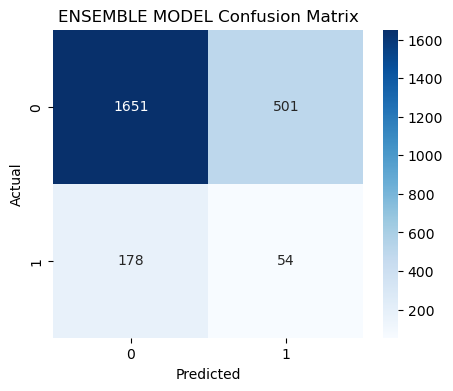

ENSEMBLE MODEL ROC AUC Score: 0.495


--- DECISION TREE Evaluation ---
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      2152
           1       0.10      0.26      0.14       232

    accuracy                           0.70      2384
   macro avg       0.50      0.50      0.48      2384
weighted avg       0.82      0.70      0.75      2384



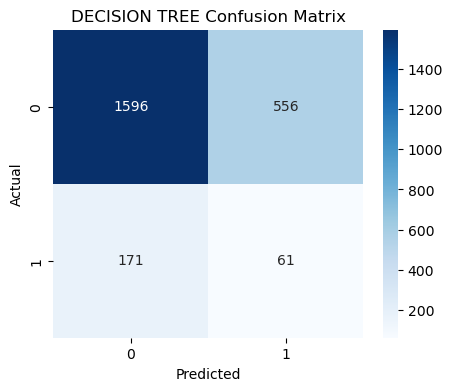

DECISION TREE ROC AUC Score: 0.500


--- RANDOM FOREST Evaluation ---
              precision    recall  f1-score   support

           0       0.90      0.65      0.76      2152
           1       0.09      0.33      0.14       232

    accuracy                           0.62      2384
   macro avg       0.50      0.49      0.45      2384
weighted avg       0.82      0.62      0.70      2384



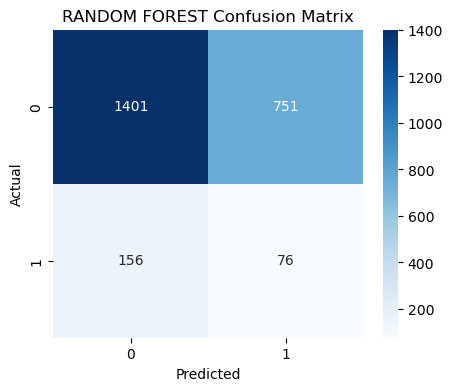

RANDOM FOREST ROC AUC Score: 0.488


--- LOGISTIC Evaluation ---
              precision    recall  f1-score   support

           0       0.90      0.74      0.81      2152
           1       0.10      0.26      0.14       232

    accuracy                           0.69      2384
   macro avg       0.50      0.50      0.48      2384
weighted avg       0.82      0.69      0.75      2384



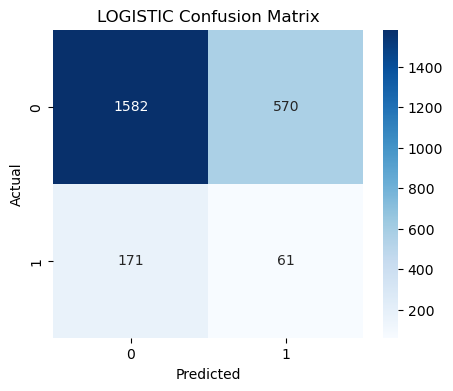

LOGISTIC ROC AUC Score: 0.502



In [156]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    print(f"\n--- {model_name} Evaluation ---")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
        print(f"{model_name} ROC AUC Score: {auc:.3f}\n")
    else:
        print()

evaluate_model(ensemble_model, X_test, y_test, "ENSEMBLE MODEL")
evaluate_model(dt_best_model, X_test, y_test, "DECISION TREE")
evaluate_model(rf_best_model, X_test, y_test, "RANDOM FOREST")
evaluate_model(logistic_model, X_test, y_test, "LOGISTIC")

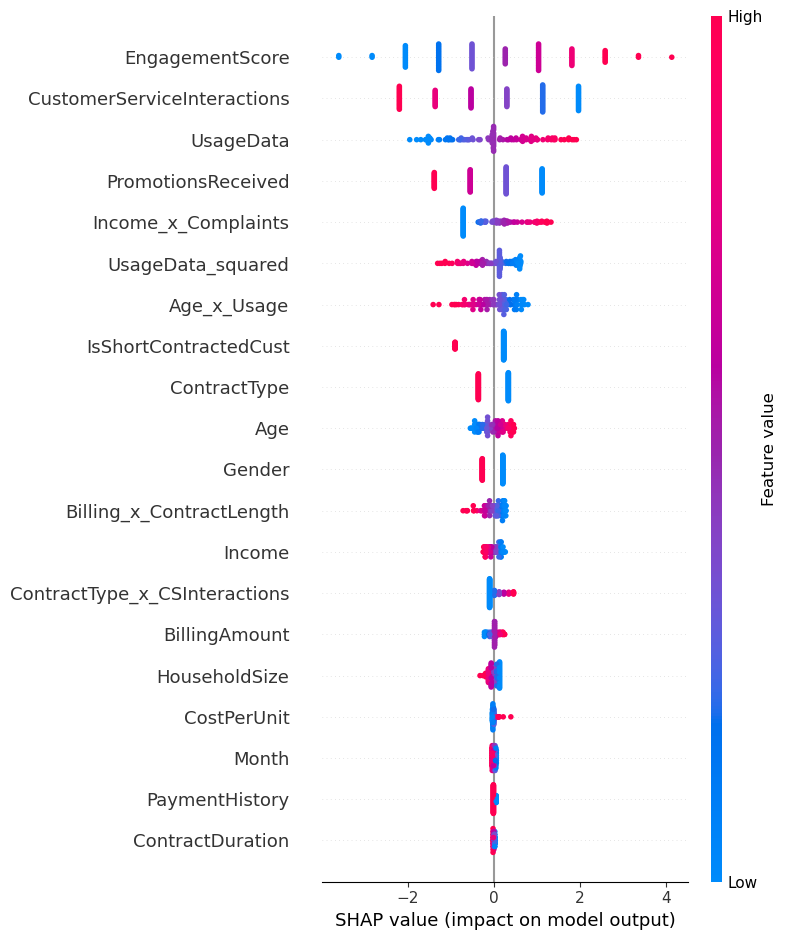

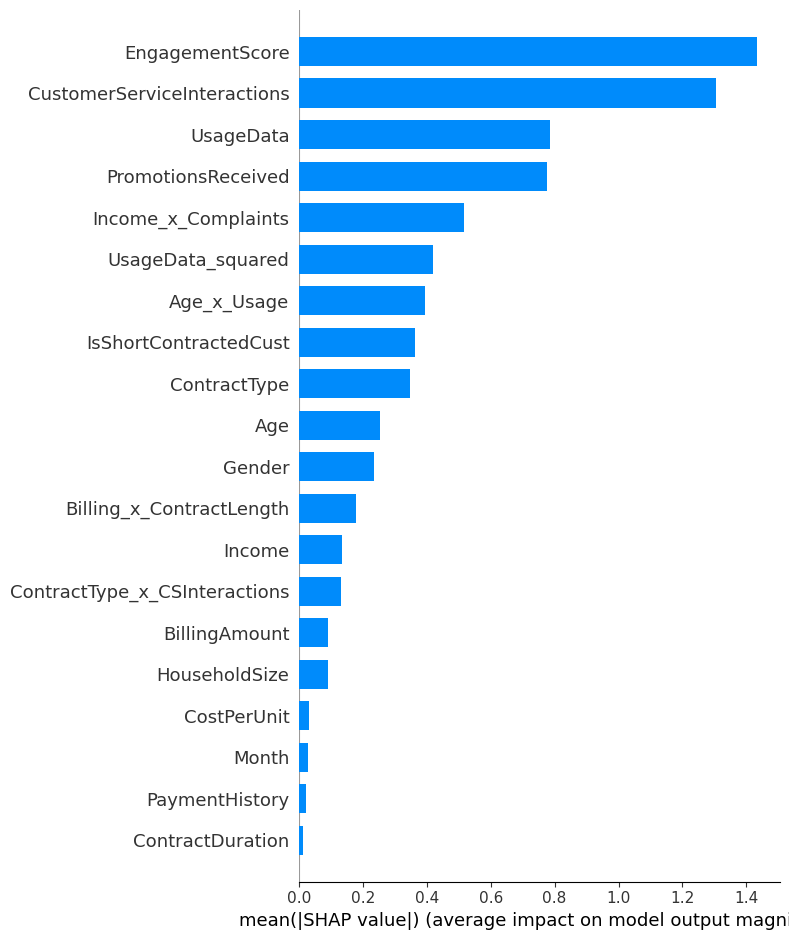

In [161]:
import shap
import matplotlib.pyplot as plt

shap.initjs()


def explain_model(model, X_sample, model_name):
   
    explainer = shap.Explainer(model, X_sample)
    shap_values = explainer(X_sample)
    
    plt.title(f"{model_name} Feature Importance")
    shap.summary_plot(shap_values, X_sample)

    plt.title(f"{model_name} Feature Effects")
    shap.summary_plot(shap_values, X_sample, plot_type="bar")

X_sample = X_test.sample(n=100, random_state=42)

# Explain random forest
explain_model(logistic_model, X_sample, "random forest")